# GX_05
# Imaging with coherent and incoherent illumination

In this graded exercise you will build and analyze the output of an imaging system that is illuminated by a coherent and incoherence source.

In [1]:
# - No modification necessary -

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2

wavelength = 633e-9
dx = 20e-6          
NA = 0.1
N = 1024

k = 2 * np.pi / wavelength

x = (np.arange(N) - N//2) * dx
y = (np.arange(N) - N//2) * dx
X, Y = np.meshgrid(x, y)

fx = np.fft.fftfreq(N, d=dx)
fy = np.fft.fftfreq(N, d=dx)
FX, FY = np.meshgrid(fx, fy)

def angular_spectrum(field, z):
    kz = np.sqrt(np.maximum(0, k**2 - (2*np.pi*FX)**2 - (2*np.pi*FY)**2))
    H = np.exp(1j * kz * z)

    F = fft2(field)
    return ifft2(F * H)

(np.float64(-0.5), np.float64(271.5), np.float64(271.5), np.float64(-0.5))

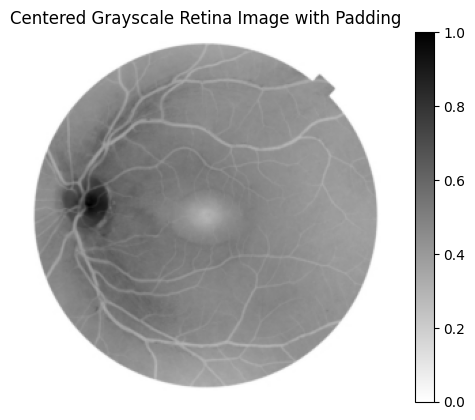

In [8]:
# - No modification necessary -

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

def load_retina_image_with_padding(N, padding=0.75):
    # Load the retina image from skimage
    retina_image = data.retina()

    # Convert to grayscale explicitly (if it's not already)
    retina_image_gray = rgb2gray(retina_image)

    # Calculate new image size
    image_size = int(N * (1 - padding))  # New size of the image to fit inside the padded domain

    # Resize the retina image to fit the padded domain
    retina_image_resized = resize(retina_image_gray, (image_size, image_size), mode='reflect', anti_aliasing=True)

    # Normalize to 0-1 range
    retina_image_resized = retina_image_resized / np.max(retina_image_resized)

    # Create a larger grid with padding
    padded_image = np.zeros((N, N))

    # Place the resized image in the center
    start = (N - image_size) // 2  # Calculate the starting index for centering
    end = start + image_size  # End index for the image

    padded_image[start:end, start:end] = retina_image_resized

    return padded_image.astype(np.complex128)

padding = 0.75
crop = int(N//2*padding-8)
# Load and pad the retina image
sample_field = load_retina_image_with_padding(N, padding)

# Display the padded retina image
plt.imshow(np.abs(sample_field)[crop:-crop, crop:-crop], cmap='gray_r')
plt.colorbar()
plt.title("Centered Grayscale Retina Image with Padding")
plt.axis('off')

# Part 1

In this part you will create the 4F system that we will be imaging through. 

Implement the four_F function the same way you have created previous four f systems, with one small modification for the lenses. Instead of generating thin lenses that cover the entire simulation domain, you will generate lenses of a finite size according to their numerical aperture. To do this, first recall the definition of NA, then apply it to calculate a circular aperture that represents the boundaries of the lens. Any light that escapes the lens should have no phase adjustment applied. The function should return the field at the output plane.

Now, employing your four_F function, implement the coherent_imaging and incoherent_imaging functions. The coherent_imaging function should return the intensity of when the input field is completely spatially coherent, and the incoherent_imaging function should return the average intensity over many samples of the output intensity of the system under spatially incoherent light.

After you have implemented these functions, use the provided plotting code to visualize the output of your system under coherent and incoherent illumination.

Once you have finished this, answer the following questions:
1) Which image appears to have a higher resolution? Does this match with theory? Which image is noisier? Does this match the theory as well? If either don't match, then why?
2) Why does the coherent image appear to have rings in it? Why doesn't the incoherent image have the same rings?
3) Is this system shift-invariant (i.e. the resolution is the same across the whole image) for coherent illumination? What about for incoherent illumination? If they are not shift-invariant, which configuration is more shift-tolerant? 

*Note: Based on the performance of your computer, you may need to reduce the number of times that the incoherent system is sampled, or you may be able to increase it. You should try to run it at as high a number of samples as possible to get the best results and answer the discussion questions based on the quality that you were able to achieve.*




In [3]:
def four_F(field, lens1_focal_length, lens2_focal_length, NA1, NA2):
    """
    Simulate the two-lens microscope system with ASM.
    
    Parameters:
    - field: input field (coherent or incoherent)
    - N: grid size (N x N)
    - wavelength: wavelength of light
    - dx: pixel size (meters)
    - lens1_focal_length: focal length of the first lens (objective lens)
    - lens2_focal_length: focal length of the second lens (eyepiece lens)
    - NA1: numerical aperture of the first (objective) lens
    - NA2: numerical aperture of the second (eyepiece) lens
    
    Returns:
    - Final image intensity after both lenses
    """
    
    # 1. Define pupil functions for each lens based on NA
    def make_pupil(f, NA):
        r_cutoff = f * NA
        pupil = ((X**2 + Y**2) <= r_cutoff**2)
        return pupil.astype(float)
    
    def lens_phase_shift(focal_length, pupil):
        """
        Compute the phase shift imparted by a thin lens.
        """
        phase_shift = np.exp(-1j * k * (X**2 + Y**2) / (2 * focal_length) * pupil)
        return phase_shift

    lens1 =  lens_phase_shift(lens1_focal_length, make_pupil(lens1_focal_length, NA1))
    lens2 = lens_phase_shift(lens2_focal_length, make_pupil(lens2_focal_length, NA2))
    
    field_before_lens_1 = angular_spectrum(field, lens1_focal_length)
    field_with_lens_1 = field_before_lens_1 * lens1
    field_after_lens_1 = angular_spectrum(field_with_lens_1, lens1_focal_length)
    
    field_before_lens_2 = angular_spectrum(field_after_lens_1, lens2_focal_length)
    field_with_lens_2 = field_before_lens_2 * lens2
    field_after_lens_2 = angular_spectrum(field_with_lens_2, lens2_focal_length)
    
    return field_after_lens_2

In [6]:
def coherent_imaging(field, lens1_focal_length, lens2_focal_length, NA1, NA2):
    """
    Perform coherent imaging using the two-lens system.
    """
    output_field = four_F(field, lens1_focal_length, lens2_focal_length, NA1, NA2)
    return np.abs(output_field)**2

def incoherent_imaging(field, lens1_focal_length, lens2_focal_length, NA1, NA2, num=1000):
    """
    Perform incoherent imaging using the two-lens system.
    """
    intensities = []
    for i in range(num):
        rand_field = field * np.exp(1j * 2 * np.pi * np.random.rand(N, N))
        output_field = four_F(rand_field, lens1_focal_length, lens2_focal_length, NA1, NA2)
        intensities.append(np.abs(output_field)**2)
    
    return np.mean(intensities, axis=0)

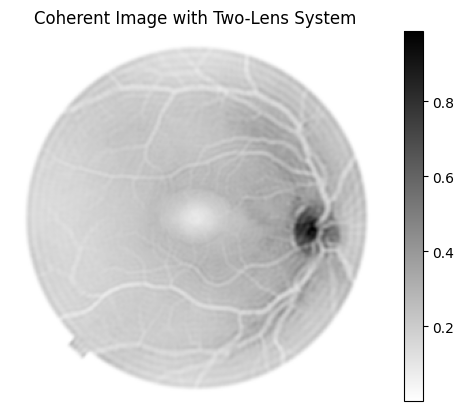

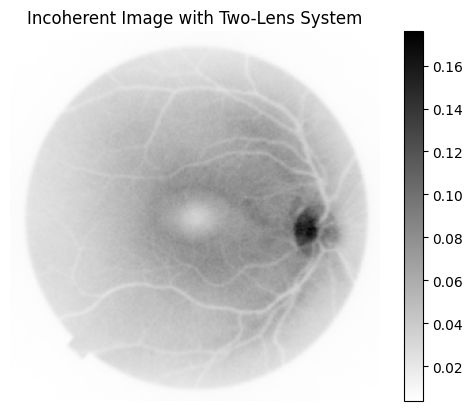

In [7]:
# - No modification necessary - 

# Parameters for the microscope system
lens1_focal_length = 0.5  # Objective lens focal length (1 mm)
lens2_focal_length = 0.5  # Eyepiece lens focal length (1 mm)
NA1 = 0.01  # Numerical aperture of the objective lens
NA2 = 0.01  # Numerical aperture of the eyepiece lens

# Use the coherent illumination field
coh_field = sample_field

# Simulate the coherent image through the two-lens system
coh_image = coherent_imaging(coh_field, lens1_focal_length, lens2_focal_length, NA1, NA2)

inc_image = incoherent_imaging(coh_field, lens1_focal_length, lens2_focal_length, NA1, NA2)

# Display the result    
plt.figure()
plt.imshow(coh_image[crop:-crop, crop:-crop], cmap='gray_r')
plt.title("Coherent Image with Two-Lens System")
plt.colorbar()
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(inc_image[crop:-crop, crop:-crop], cmap='gray_r')
plt.title("Incoherent Image with Two-Lens System")
plt.colorbar()
plt.axis('off')
plt.show()

## Discussion
1) The incoherent image appears to have a higher resolution than the coherent image, which matches with the theoretical expectation. The incoherent image also appears to be a bit noisier than the coherent image, which matches our expectation of incoherent imaging with a finite amount of sampling. If we were to run to infinite samples or to directly calculate the incoherent output through the system's transfer function, we would expect that the image should be noise free.
2) The rings in the coherent image arise from the finite boundaries of the lenses, as determined by their NAs. At these locations we observe strong diffraction for coherent illumination, which leads to a resulting visible pattern. Incoherent illumination does not experience consistent diffraction from the edges, so the net effect is washed out and no rings are visible.
3) Due to the finite size of the lenses, this system is not shift-invariant for coherent illumination, as more information will escape for pixels that are farther away from the center of the input. Incoherent illumination experiences the same effect, meaning that it is not shift-invariant, but due to the ability of the system to pass more spatial frequencies under incoherent illumination, the incoherent setup will be more "shift-tolerant" than the coherent setup.

# Bonus

The image of an eye that you have been working with was most likely acquired using a fundus camera. Below is a diagram of what a fundus camera might look like:

<div style="text-align: center;">
    <br>
    <a href="https://www.researchgate.net/figure/Working-principle-of-fundus-camera-The-beam-from-the-annular-source-passes-through-the_fig2_289634428"><img src="https://www.researchgate.net/profile/Chen-Ma-4/publication/289634428/figure/fig2/AS:631980903391254@1527687397346/Working-principle-of-fundus-camera-The-beam-from-the-annular-source-passes-through-the.png" alt="Working principle of fundus camera. The beam from the annular source passes through the illumination system and the edge of pupil and reaches the fundus tissue. And light reflected by the fundus is collected by the imaging system."/></a>
    <p>    
        Ma, Chen & Cheng, Dewen & Xu, Chen & Wang, Yongtian. (2014). Design, simulation and experimental analysis of an anti-stray-light illumination system of fundus camera. Proceedings of SPIE - The International Society for Optical Engineering. 9272. 10.1117/12.2073619. 
    </p>
    <br>
</div>

In some setups, incoherent light is used to illuminate the eye, and in others, coherent light is used. Take some time to learn about the fundus camera through the internet and the provided paper, then answer the following question:

Which type of source do you think is being used in this setup and what evidence from the diagram can you use to justify your determination?

## Discussion
This microscope is based on an incoherent source. Typically in a fundus microscope, incoherent illumination will be used for wide-field imaging and coherent illumination will be used for scanning imaging. We can clearly see from this diagram that this specific microscope is performing wide-field imaging, so we assume its source must be incoherent.